#A. DATA PREPARATION

##1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# Mengatur tampilan
pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

##2. Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Upload dataset terlebih dahulu ke Google Colab
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/LSP - sultan hafidzh polihito/datasetPraktikum - WA_Fn-UseC_-Telco-Customer-Churn.csv'
)

#B. DATA UNDERSTANDING

##1. Menampilkan Dataset

In [ ]:
print("5 Data Teratas:")
display(df.head())

print("\n5 Data Terbawah:")
display(df.tail())

5 Data Teratas:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



5 Data Terbawah:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No


##2. Ukuran Dataset

In [ ]:
print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])
print("Ukuran Dataset:", df.shape)

Jumlah Baris : 7043
Jumlah Kolom : 21
Ukuran Dataset: (7043, 21)


##3. Informasi Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


##4. Statistik Deskriptif

In [ ]:
print("Statistik Deskriptif Numerik:")
display(df.describe())

print("\nStatistik Deskriptif Kategorikal:")
display(df.describe(include='object'))

Statistik Deskriptif Numerik:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000



Statistik Deskriptif Kategorikal:


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,4,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3539,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


##5. Identifikasi Tipe Data

In [ ]:
data_types = pd.DataFrame({
    'Kolom': df.columns,
    'Tipe Data': df.dtypes.astype(str).values,
    'Jumlah Nilai Unik': df.nunique().values
})

display(data_types)

,Kolom,Tipe Data,Jumlah Nilai Unik
0,customerID,object,7043
1,gender,object,4
2,SeniorCitizen,int64,2
3,Partner,object,2
4,Dependents,object,2
5,tenure,int64,73
6,PhoneService,object,2
7,MultipleLines,object,3
8,InternetService,object,3
9,OnlineSecurity,object,3


##6. Missing Values

In [ ]:
missing = df.isnull().sum()

print("Missing value setiap kolom:")
print(missing)

Missing value setiap kolom:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


##7. Duplicate

In [ ]:
duplicate_count = df.duplicated().sum()
print("Jumlah data duplicate:", duplicate_count)

Jumlah data duplicate: 0


##8 Distribusi nilai pada kolom gender

In [ ]:
print(df['gender'].value_counts(dropna=False))

gender
Male      3539
Female    3464
F           24
M           16
Name: count, dtype: int64


##9. Distribusi Target

In [ ]:
print("Distribusi Target:")
print(df['Churn'].value_counts())

print("\nPersentase Target:")
print(
    (df['Churn'].value_counts(normalize=True) * 100).round(2)
)

Distribusi Target:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Persentase Target:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


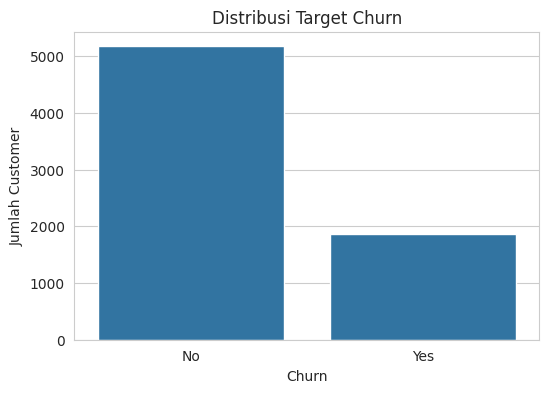

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='Churn'
)

plt.title('Distribusi Target Churn')
plt.xlabel('Churn')
plt.ylabel('Jumlah Customer')

plt.show()

#C. DATA CLEANING

##1. Menghapus Duplicate

In [ ]:
print("Jumlah data sebelum menghapus duplicate:", len(df))
df = df.drop_duplicates()
print("Jumlah data setelah menghapus duplicate:", len(df))

Jumlah data sebelum menghapus duplicate: 7043
Jumlah data setelah menghapus duplicate: 7043


##2. Menangani Missing / Empty Values

In [ ]:
# Mengubah whitespace menjadi NaN
df = df.replace(r'^\s*$', np.nan, regex=True)
print("Missing values setelah mendeteksi empty values:")
display(
    df.isnull().sum().sort_values(ascending=False)
)

Missing values setelah mendeteksi empty values:


,0
TotalCharges,11
gender,0
SeniorCitizen,0
Partner,0
customerID,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0


##3. Konversi Tipe Data

In [ ]:
# Mengubah TotalCharges menjadi numerik
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print("Tipe data setelah konversi:")
print(df['TotalCharges'].dtype)

Tipe data setelah konversi:
float64


In [ ]:
# Mengisi missing value pada TotalCharges
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

# Mengecek kembali missing values
print("Total missing values setelah cleaning:")
print(df.isnull().sum().sum())

Total missing values setelah cleaning:
0


##4. Menghapus Kolom Tidak Relevan

In [ ]:
print("Kolom sebelum penghapusan:")
print(df.columns.tolist())

# Menghapus customerID
df = df.drop(columns=['customerID'])
print("\nKolom setelah penghapusan:")
print(df.columns.tolist())

Kolom sebelum penghapusan:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Kolom setelah penghapusan:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
print("Ukuran dataset setelah cleaning:", df.shape)
display(df.head())

Ukuran dataset setelah cleaning: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#D. EXPLORATORY DATA ANALYSIS (EDA)

##1. Distribusi Target

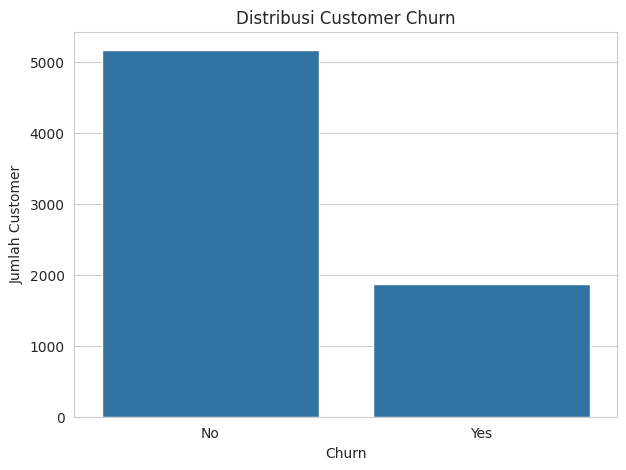

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x='Churn'
)

plt.title('Distribusi Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Jumlah Customer')
plt.show()

In [ ]:
#Presentase
churn_percentage = (
    df['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


##2. Distribusi Fitur Numerik

In [ ]:
numerical_features = df.select_dtypes(
    include=['int64', 'float64']
).columns

print("Fitur Numerik:")
print(list(numerical_features))

Fitur Numerik:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


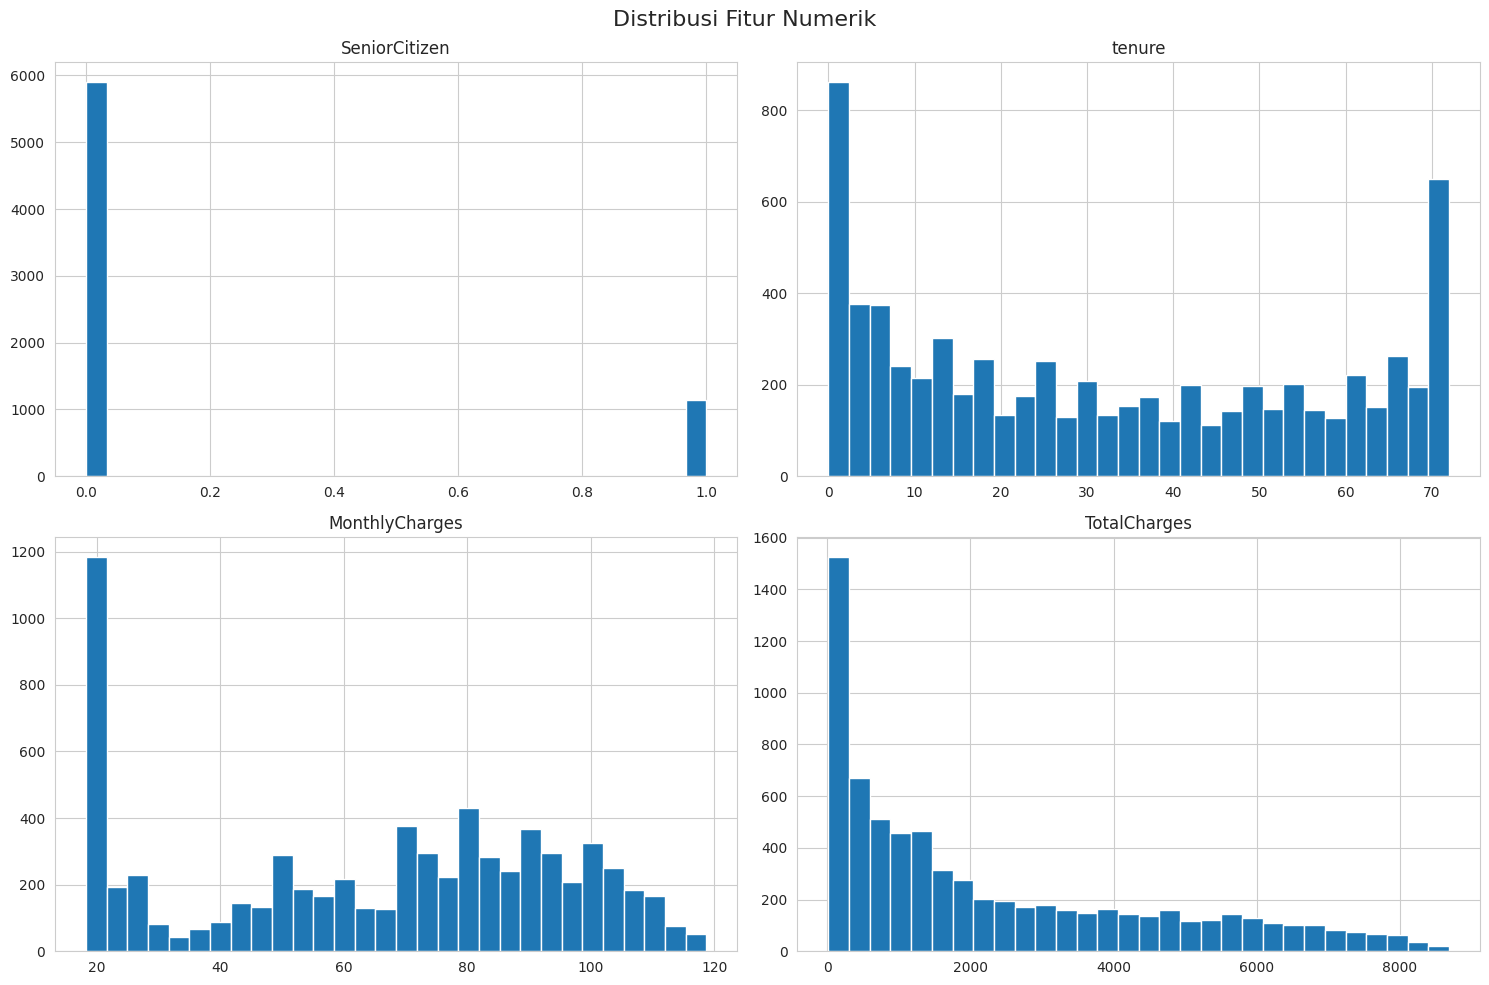

In [ ]:
#Histogram
df[numerical_features].hist(
    figsize=(15, 10),
    bins=30
)
plt.suptitle(
    'Distribusi Fitur Numerik',
    fontsize=16
)
plt.tight_layout()
plt.show()

##3. Analisis Fitur Kategorikal

In [ ]:
categorical_features = df.select_dtypes(
    include='object'
).columns

print("Fitur Kategorikal:")
print(list(categorical_features))

Fitur Kategorikal:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


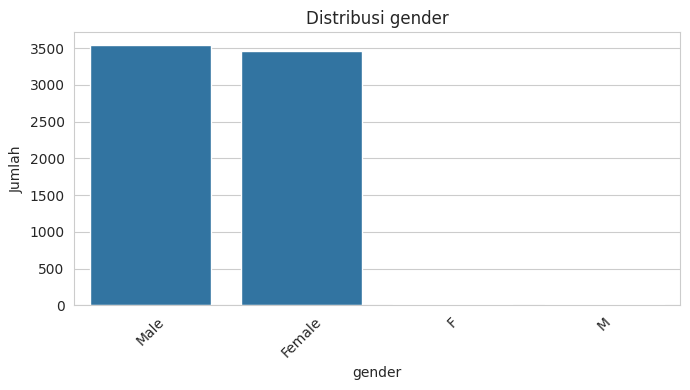

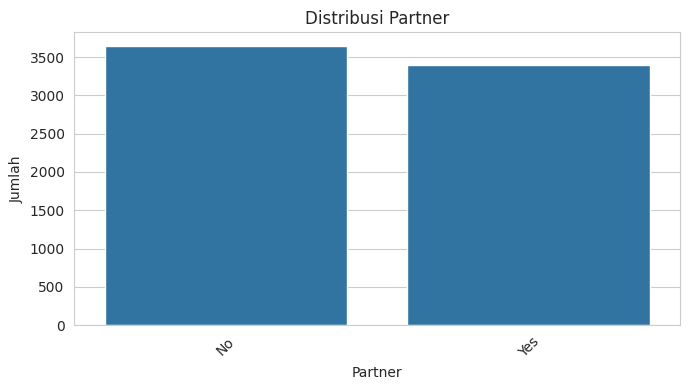

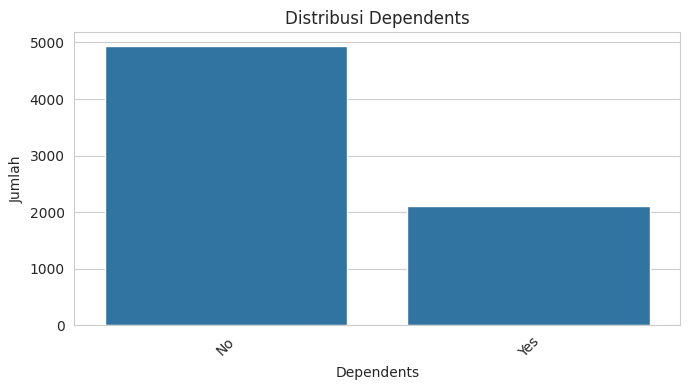

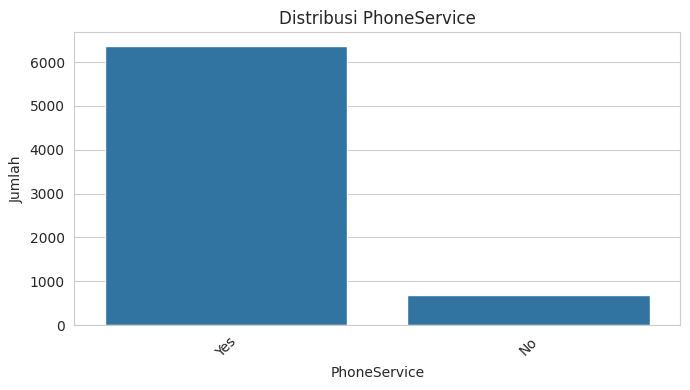

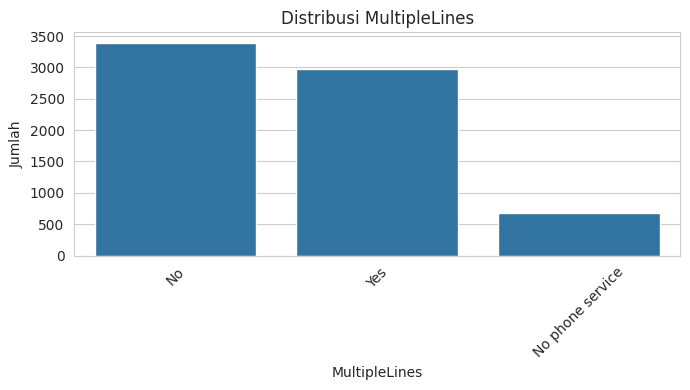

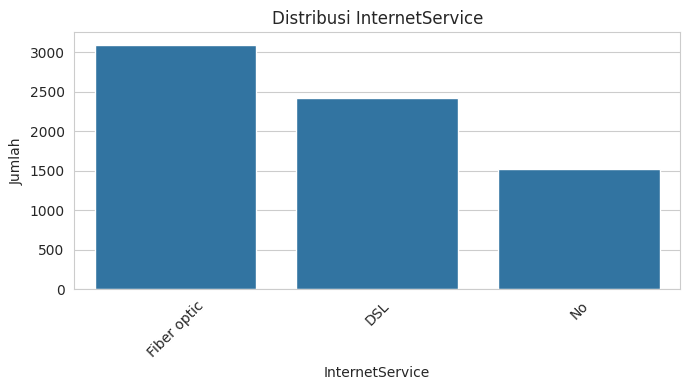

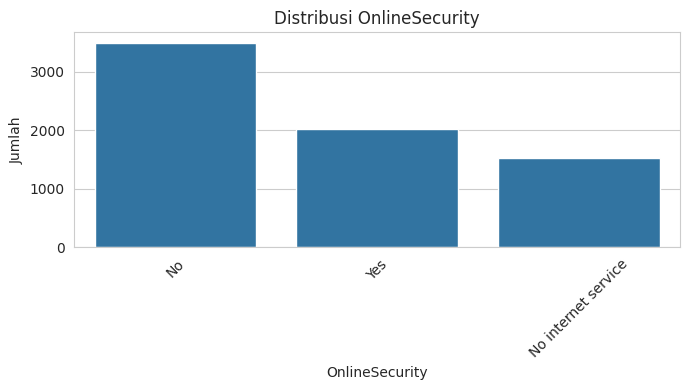

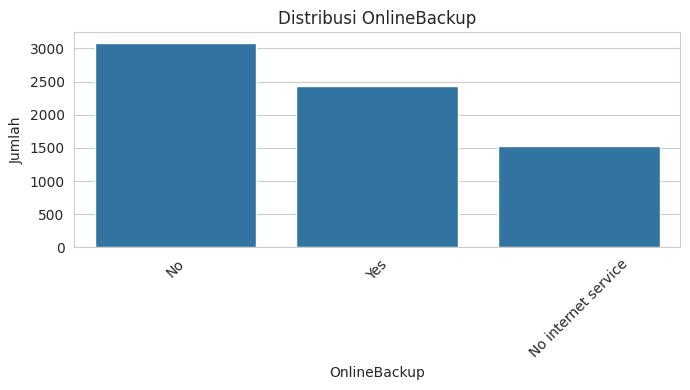

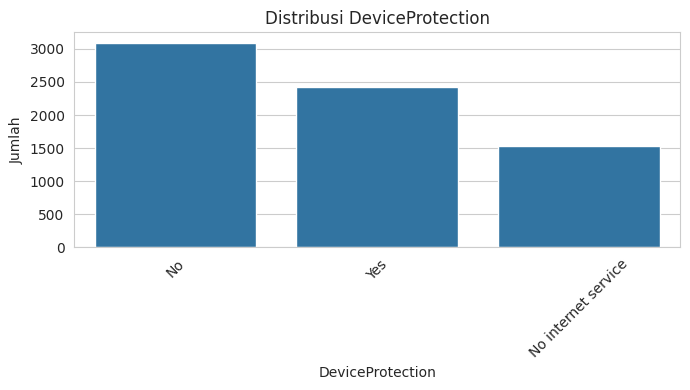

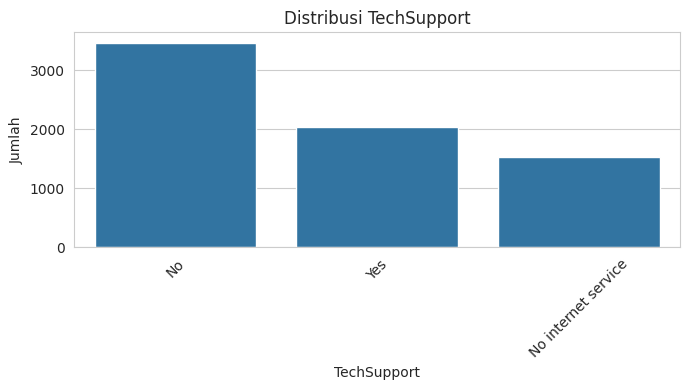

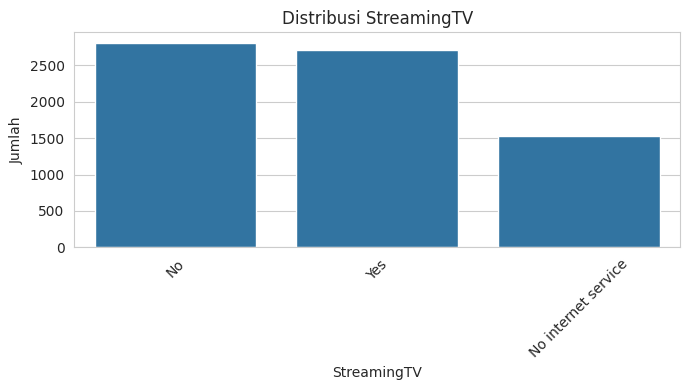

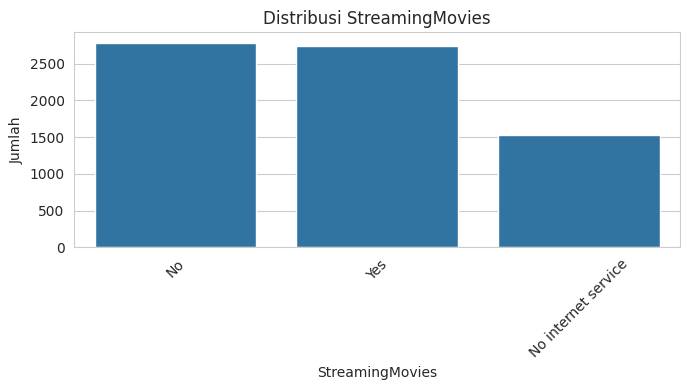

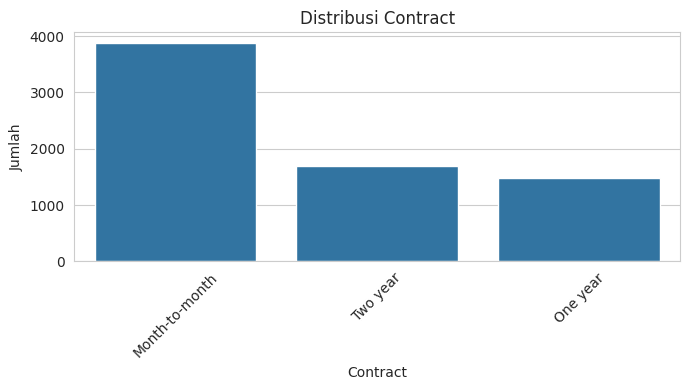

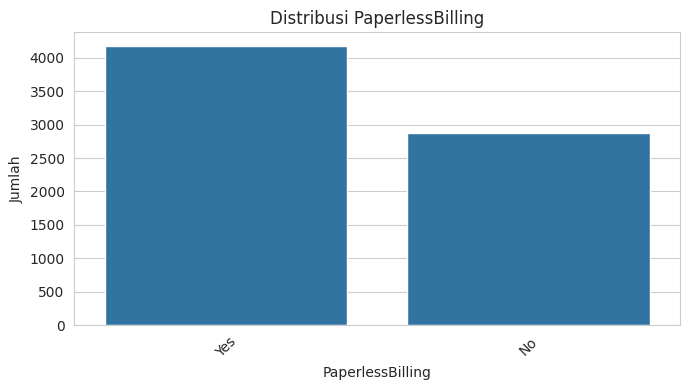

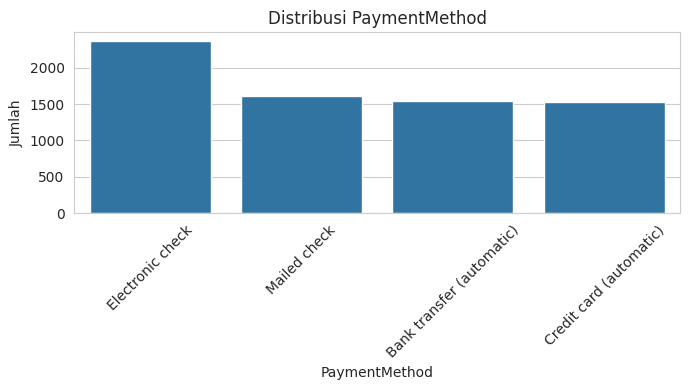

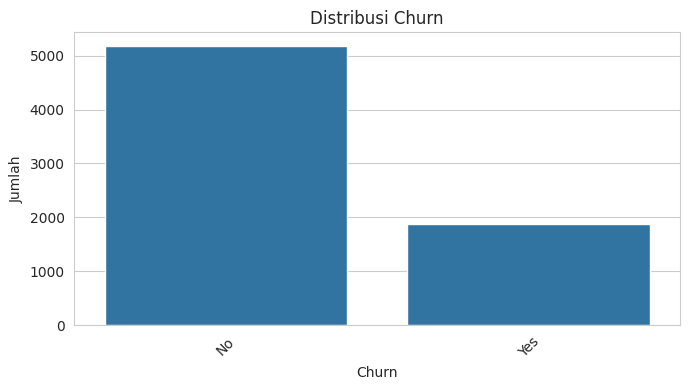

In [ ]:
#Visual
for col in categorical_features:
    plt.figure(figsize=(7, 4))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Jumlah')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

##4. Hubungan Fitur dengan Target

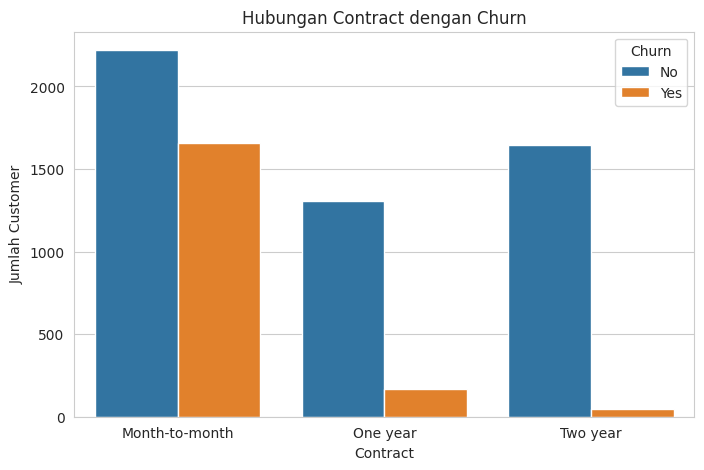

In [ ]:
#Contract vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='Contract', #bisa di ganti Internet Service, Payment Method, Tenure, dan Monthly Charges.
    hue='Churn'
)

plt.title('Hubungan Contract dengan Churn')
plt.xlabel('Contract') #kalau mau ganti dibagian si x, disini juga harus disamain
plt.ylabel('Jumlah Customer')
plt.show()

##5. Correlation Analysis

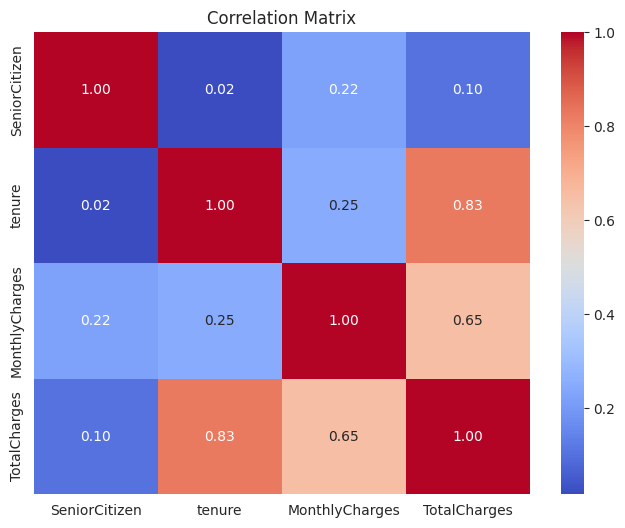

In [ ]:
correlation_matrix = df[numerical_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.show()

##6. Outlier Analysis

In [ ]:
for col in numerical_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}")
    print(f"Jumlah outlier: {len(outliers)}")
    print("-" * 40)

SeniorCitizen
Jumlah outlier: 1142
----------------------------------------
tenure
Jumlah outlier: 0
----------------------------------------
MonthlyCharges
Jumlah outlier: 0
----------------------------------------
TotalCharges
Jumlah outlier: 0
----------------------------------------


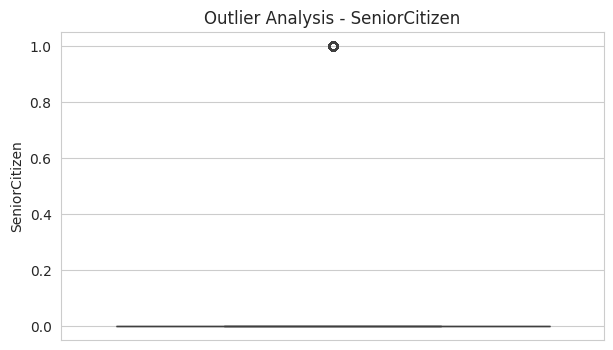

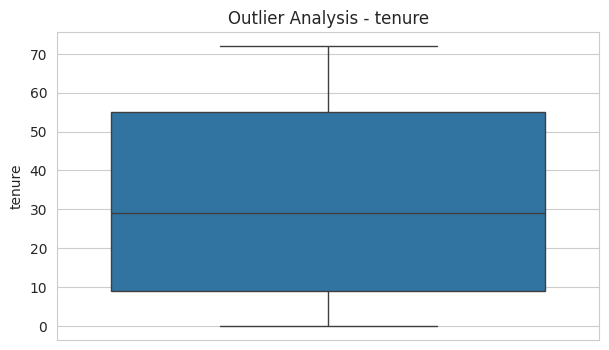

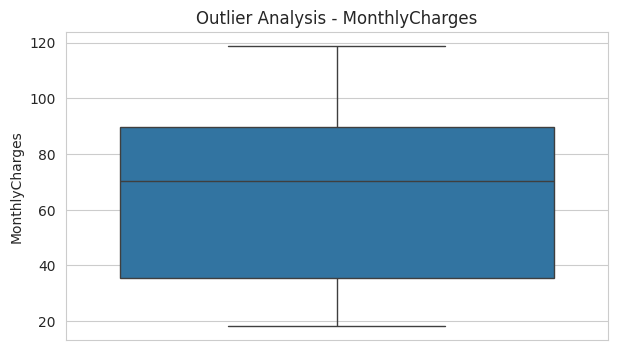

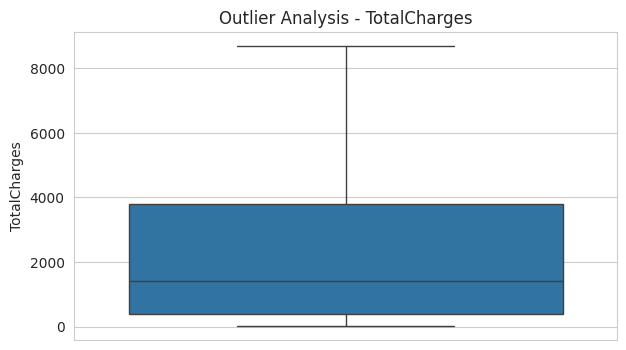

In [ ]:
#visualisasi
for col in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(
        data=df,
        y=col
    )

    plt.title(f'Outlier Analysis - {col}')
    plt.ylabel(col)
    plt.show()

#E. DATA PREPROCESSING

##1. Menentukan X dan y

In [ ]:
X = df.drop(columns=['Churn'])

y = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

print("X:")
display(X.head())

print("\ny:")
display(y.head())

X:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65



y:


,Churn
0,0
1,0
2,1
3,0
4,1


##2. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Jumlah data training :", X_train.shape)
print("Jumlah data testing  :", X_test.shape)

Jumlah data training : (5634, 19)
Jumlah data testing  : (1409, 19)


##3. Numerical Pipeline

In [ ]:
numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

##4. Categorical Pipeline

In [ ]:
categorical_features = X.select_dtypes(
    include=['object']
).columns

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

##5. Encoding

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[(
            'numerical',
            numerical_pipeline,
            numerical_features
        ),
        (  'categorical',
            categorical_pipeline,
            categorical_features
        )
    ]
)

#F. MODELING

In [ ]:
# 1. Logistic Regression
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression berhasil dilatih.")

Logistic Regression berhasil dilatih.


In [ ]:
# 2. Decision Tree
decision_tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree berhasil dilatih.")

Decision Tree berhasil dilatih.


In [ ]:
# 3. Random Forest
random_forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10
    ))
])

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest berhasil dilatih.")

Random Forest berhasil dilatih.


#G. MODEL EVALUATION

##1–5. Accuracy, Precision, Recall, F1-Score,

In [ ]:
models = {
    'Logistic Regression': logistic_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model
}

results = []

for name, model in models.items():

    # Prediksi kelas
    y_pred = model.predict(X_test)

    # Prediksi probabilitas
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
    })

# Membuat DataFrame hasil evaluasi
results_df = pd.DataFrame(results)

# Membulatkan nilai
results_df[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score']
] = results_df[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score']
].round(4)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8027,0.6519,0.5508,0.5971
1,Decision Tree,0.7984,0.6347,0.5668,0.5989
2,Random Forest,0.8006,0.6587,0.5160,0.5787


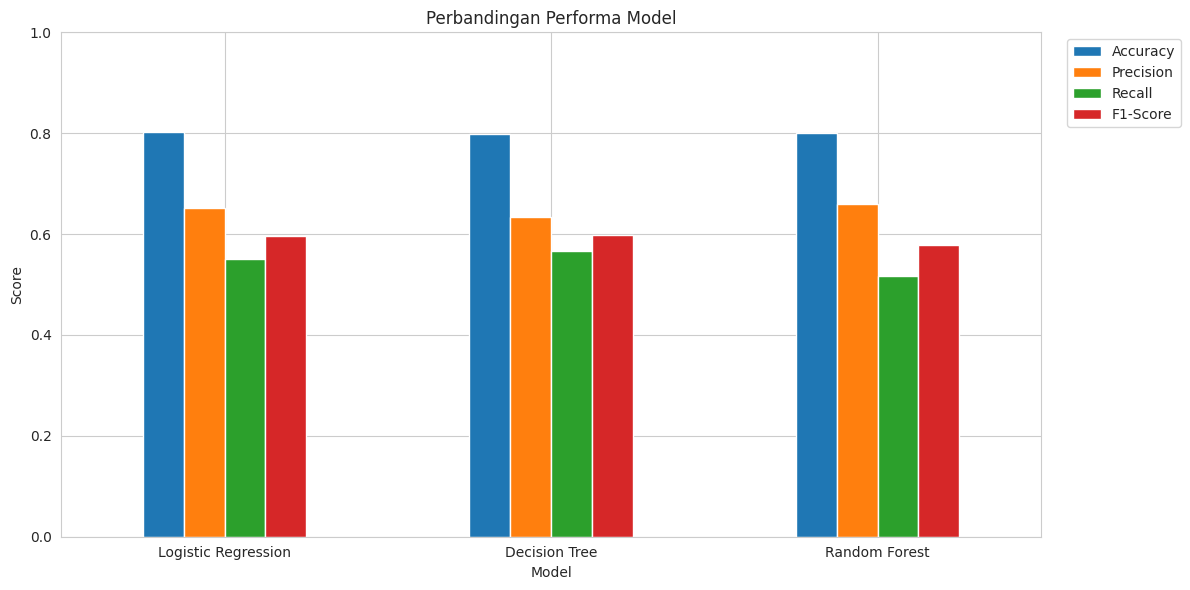

In [ ]:
#Visualisasi perbandingan model
results_plot = results_df.set_index('Model')

results_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Perbandingan Performa Model')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

##6. Confusion Matrix

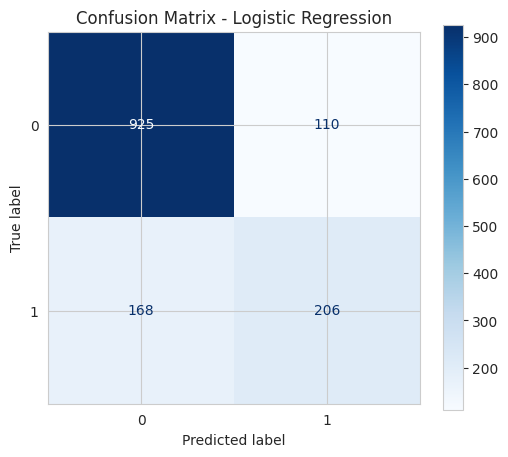

In [ ]:
# Confusion Matrix - Logistic Regression
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test,
    cmap='Blues',
    ax=ax
)

plt.title('Confusion Matrix - Logistic Regression')
plt.show()

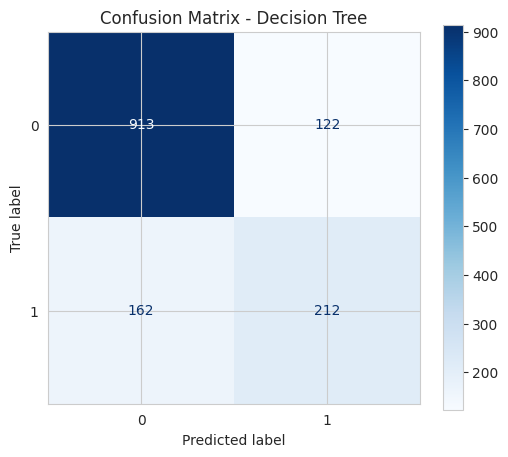

In [ ]:
# Confusion Matrix - Decision Tree
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    decision_tree_model,
    X_test,
    y_test,
    cmap='Blues',
    ax=ax
)

plt.title('Confusion Matrix - Decision Tree')
plt.show()

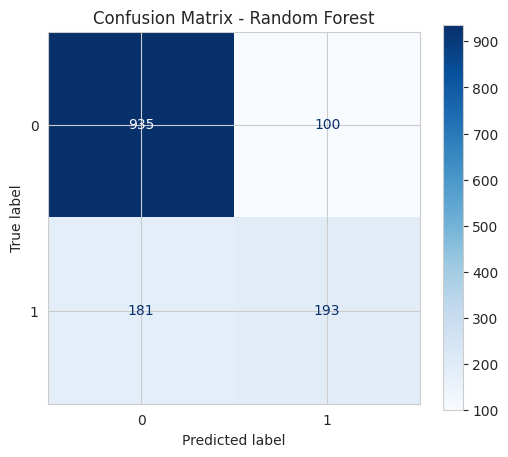

In [ ]:
# Confusion Matrix - Random Forest
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    random_forest_model,
    X_test,
    y_test,
    cmap='Blues',
    ax=ax
)

plt.title('Confusion Matrix - Random Forest')
plt.show()

##7. Classification Report

In [ ]:
for name, model in models.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    y_pred = model.predict(X_test)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=['No Churn', 'Churn']
        )
    )

Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

Decision Tree
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.87      1035
       Churn       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Random Forest
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79   